## Segmentation for Merscope 
Adapted from:
T. Defard, https://github.com/tdefa/tuto_crop_segment_merfish

Original author: Thomas Defard.
Used with permission.

In [6]:
import pandas as pd
import numpy as np
from pathlib import Path
import json
from tqdm import tqdm
import tifffile
import matplotlib.pyplot as plt
import os as os


#import torch
#from cellpose import models 


## Test Cellpose2 segmentation

We provide two custome Cellpose2 models tailered for Xenopus.laevis. 

Model_1 is trained on sections from late gastrula (Stage 12.5) and tailbud (Stage 22) embryos, with default diameter suitable for neurula to tailbud stage embryos.

Model_2 is trained on sections from blastula (Stage 9) and gastrula (Stages 10.5, 11 and 12) embryos, with default diameter suitable for gastrula stage embryos.

You can firstly test if the model provided can segment your sections well.
Use Cellbound3 and DAPI as first choice for segmentation. 
The "diameter" parameter could be adjust according to your own samples, if the default diameter doesn't work well.

The guidance to segment cells with Cellpose2: https://cellpose.readthedocs.io/en/latest/index.html

## Manually select a regions of interest (ROI) 

To test segmentation with cellpose or other algoritm, also prepare for custom-trained model. It is better to select a small ROI like section


In [12]:
## PATH 
## create a folder to save the result
this_path = os.getcwd()
path_to_region = os.getcwd() + "/region_crop"
Path(path_to_region).mkdir(parents=True, exist_ok=True)
path_to_save_crop = path_to_region + "/crop3"
Path(path_to_save_crop).mkdir(parents=True, exist_ok=True)
#path_to_save_crop_csv = path_to_save_crop + "/csv"
#Path(path_to_save_crop_csv).mkdir(parents=True, exist_ok=True)
path_to_save_crop_img = path_to_save_crop + "/images"
Path(path_to_save_crop_img).mkdir(parents=True, exist_ok=True)

Plot the entire image first to know where to crop

In [14]:
DAPI = tifffile.imread(this_path + "/data/images/mosaic_DAPI_z3.tif")

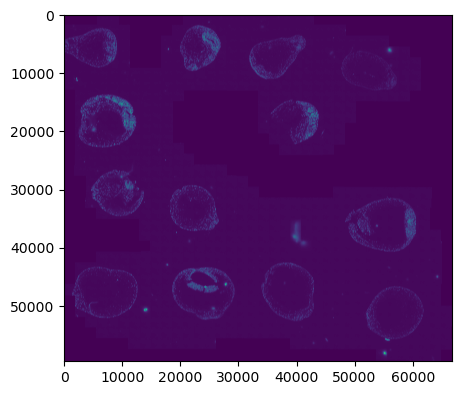

In [15]:
## Vizualise the whole slide so you choose the embrio you want to study, this step take can take few minutes
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.imshow(DAPI)
plt.show()


In [16]:
### select the coordinates of the ROI you want
crop_min_x = 31000
crop_max_x = 43000
crop_min_y = 2000
crop_max_y = 12000

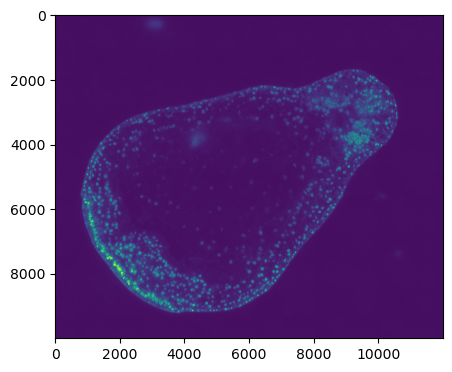

In [18]:

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.imshow(DAPI[crop_min_y:crop_max_y,crop_min_x:crop_max_x])
plt.show()

In [21]:
## save the cropped images
## Choose Cellbound3 and DAPI for segmentation  

path_tiff_folder = Path(this_path  + "/data/images")
for path_tiff in tqdm(list(path_tiff_folder.glob("*_z3.tif"))):
    try : 
        tiff = tifffile.imread(path_tiff)
        tifffile.imwrite(Path(path_to_save_crop_img) / path_tiff.name, tiff[crop_min_y:crop_max_y,crop_min_x:crop_max_x])
    except Exception as e:
        print(e)
        print(f"{path_tiff.name} where not save")
        pass


100%|████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:22<00:00, 11.10s/it]


## If retrain the Cellpose2 model

If you need to improve the perfomance of the model, you need to manually annotate some cells yourself on few tiles so the model can be'retrained' on these good examples  

the first step is crop some tiles (small images)


In [22]:
## Crop some tiles 

## set channel name
chanel1 = "mosaic_Cellbound3_z3"
chanel2 = "mosaic_DAPI_z3"


### load the Z stack / cellbound you want to tile
im1 = tifffile.imread(path_to_save_crop_img + f"/{chanel1}.tif")
im2 = tifffile.imread(path_to_save_crop_img + f"/{chanel2}.tif")

## set the tilling dimmension, here a 10x10 grid
M = im1.shape[0] // 10
N = im1.shape[1] // 10

im = np.array([im1, im2]) # merge channels

tiles = [{str(x)+'_'+str(y) :  im[:, x:x + M, y:y + N]} for x in range(0,im1.shape[0], M) 
         for y in range(0, im1.shape[1], N)]

## save the tiles for latter used
path_to_save_crop_tiles = path_to_save_crop_img + '/cellbound3_dapi'
Path(path_to_save_crop_tiles).mkdir(parents=True, exist_ok=True)

for t in tiles:
    for k in t:
        tifffile.imwrite(Path(path_to_save_crop_tiles) / (k +'.tif'), t[k])
        

Then you can use the cellpose GUI to annotate and re-train your model.  
If not already, install cellpose GUI by doing ``python -m pip install cellpose[gui]`` in a terminal

lunch it with ``python -m cellpose`` in a terminal and follow the guideline here: https://cellpose.readthedocs.io/en/latest/gui.html

<img src="../images//annotation.png" alt="annotation" width="90%"/>

## Resegmentation of the dataset

When you are satisfied with the cell segmentation on a cropped section, you can apply the custome cellpose2 model on VPT (Vizgen post-processing tool) to resegment the Merscope data.

The guidance to use VPT (Version 1.3): https://vizgen.github.io/vizgen-postprocessing/analysis_vignettes/segmentation_heart_dataset_cellpose2.html

### Channels to use:

Cellbound3 and DAPI

If Cellbound3 staining is in low-quality, you can try to merge the Cellbound1 and Cellbound3 channels for input as membrane staining. 


### Command Line Usage:

### Segmentation:

vpt --verbose --processes 8 run-segmentation --segmentation-algorithm cellpose2_custom_Model2.json --input-images="C:\Users\Users.OFFLINE-1\Desktop\Chenxi_zhou_test_VPT\Exp2_region1\mosaic_(?P<stain>[\w|-]+)_z(?P<z>[0-9]+).tif" --input-micron-to-mosaic micron_to_mosaic_pixel_transform.csv --output-path analysis_outputs --tile-size 2400 --tile-overlap 200


### Generate genn_by_cell matrix:
    
vpt --verbose partition-transcripts --input-boundaries analysis_outputs\cellpose2_micron_space.parquet --input-transcripts C:\Users\Users.OFFLINE-1\Desktop\Chenxi_zhou_test_VPT\Exp2_region1\detected_transcripts.csv --output-entity-by-gene analysis_outputs\cell_by_gene.csv
    
### Generate cell metadata:
    
vpt --verbose derive-entity-metadata --input-boundaries analysis_outputs/cellpose2_micron_space.parquet --output-metadata analysis_outputs/cell_metadata.csv

### Update .vzg2 file for visualizer (Merscope data wrapped in .vzg2 file can be visaulized in Merscope visaulizer)

vpt --verbose --processes 8 update-vzg --input-vzg Merscope02_region_1.vzg2 --input-boundaries analysis_outputs/cellpose2_micron_space.parquet --input-entity-by-gene analysis_outputs/cell_by_gene.csv --output-vzg analysis_outputs/Merscope02_region_1_cellpose2.vzg2
    